In [40]:
# Importing the necessary libraries and modules

import sys
import os

sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import custom visualization functions
import src.visualization as viz
import src.data_cleaning as cleaning
import src.statistical_tests as st




In [41]:
# Use relative path instead of absolute path. 
file_path = '../data/raw/user_behavior_dataset.csv'


In [42]:
# Loading the dataset into a dataframe called df
df = pd.read_csv(file_path)

In [43]:
# Making a copy of the dataframe in order to preserve the original dataset.
mobile_user = df.copy()

In [44]:
# Examine the first 5 rows of the dataset. 
mobile_user.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [45]:
# Get the number of rows and columns of the dataset
mobile_user.shape

(700, 11)

In [46]:
# Get the general info on the dataset
mobile_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


In [47]:
# Is there any missing value in this dataset.
mobile_user.isna().sum().sum()

0

In [48]:
# How many duplicates are they in the dataset
mobile_user.duplicated().sum()

0

In [49]:
# Get some statistical informations about the dataset
mobile_user.describe()

,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [50]:
# Convert the 'Screen On Time'from hours to minutes
mobile_user['Screen on Time min/day']= mobile_user['Screen On Time (hours/day)'] * 60

In [51]:
# Drop the old column 'Screen On Time' in hours
mobile_user.drop(['Screen On Time (hours/day)'],axis = 1, inplace = True)


#### Let's Standardize the column names

In [52]:
mobile_user = cleaning.standardize_columns(mobile_user)

In [53]:
mobile_user.head()

,user_id,device_model,operating_system,app_usage_time_min_per_day,battery_drain_mah_per_day,number_of_apps_installed,data_usage_mb_per_day,age,gender,user_behavior_class,screen_on_time_min_per_day
0,1,Google Pixel 5,Android,393,1872,67,1122,40,Male,4,384.0
1,2,OnePlus 9,Android,268,1331,42,944,47,Female,3,282.0
2,3,Xiaomi Mi 11,Android,154,761,32,322,42,Male,2,240.0
3,4,Google Pixel 5,Android,239,1676,56,871,20,Male,3,288.0
4,5,iPhone 12,iOS,187,1367,58,988,31,Female,3,258.0


In [54]:
cleaned_path = '/Users/akoweatty/mobile_communication/data/cleaned/mobile_user_cleaned.csv'
mobile_user.to_csv(cleaned_path, index = False)


 A) Numerical features 

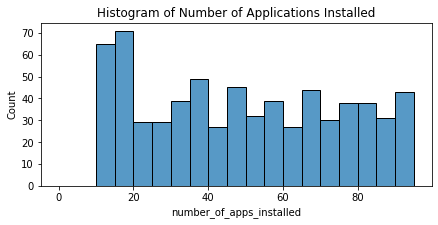

In [55]:
# Histogram representing the 'Number of Apps Installed' by the mobile users

plt.figure(figsize = (7,3))

sns.histplot(mobile_user['number_of_apps_installed'],bins=range(0, mobile_user['number_of_apps_installed'].max()+1,5))

plt.title("Histogram of Number of Applications Installed")
plt.show()

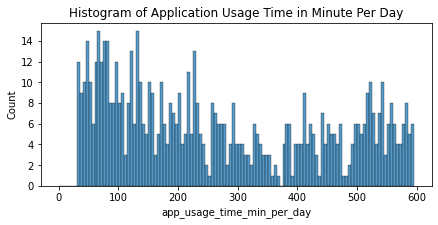

In [56]:
# Histogram representing "App Usage Time (min/day)"

plt.figure(figsize = (7,3))
sns.histplot(mobile_user['app_usage_time_min_per_day'],bins=range(0, mobile_user['app_usage_time_min_per_day'].max()+1,5))
plt.title("Histogram of Application Usage Time in Minute Per Day")
plt.show()

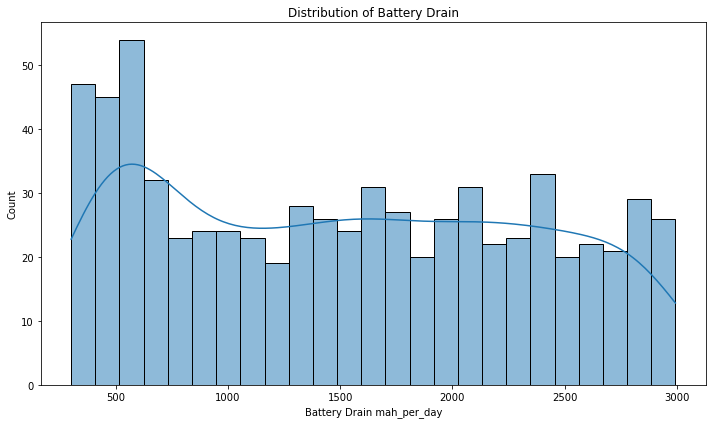

In [57]:
viz.plot_battery_drain_distribution(mobile_user)

B) Categorical features

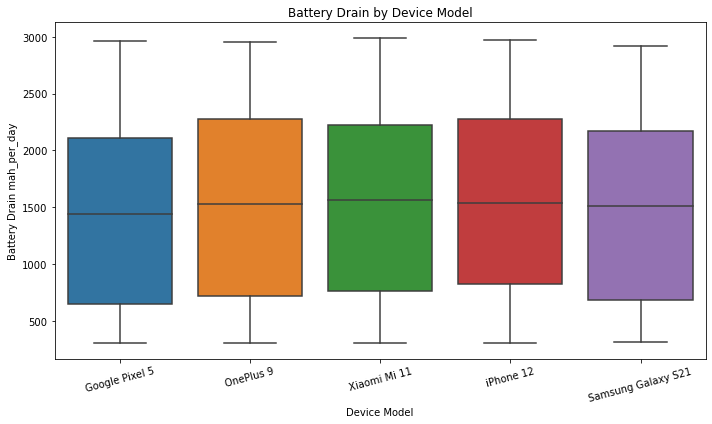

In [58]:
viz.plot_battery_drain_by_device(mobile_user)

<AxesSubplot:xlabel='device_model', ylabel='number_of_apps_installed'>

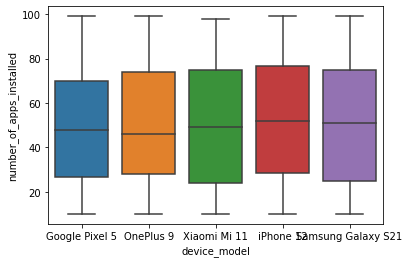

In [59]:
# Number of applications installed and device model

sns.boxplot(x="device_model", y="number_of_apps_installed", data = mobile_user)

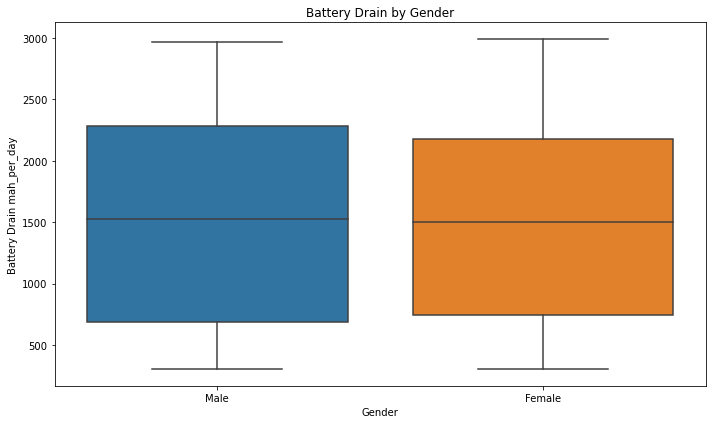

In [60]:
viz.plot_battery_drain_by_gender(mobile_user)

<AxesSubplot:xlabel='gender', ylabel='number_of_apps_installed'>

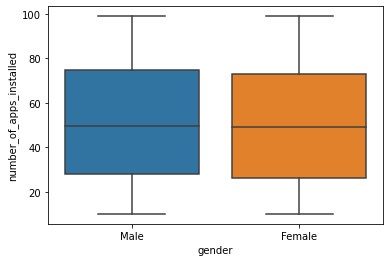

In [61]:
# Number of applications installed and gender

sns.boxplot(x="gender", y="number_of_apps_installed", data = mobile_user)

In [62]:
# Number of mobile users by device model
mobile_user_counts = mobile_user['device_model'].value_counts()
mobile_user_counts.head()

Xiaomi Mi 11          146
iPhone 12             146
Google Pixel 5        142
OnePlus 9             133
Samsung Galaxy S21    133
Name: device_model, dtype: int64

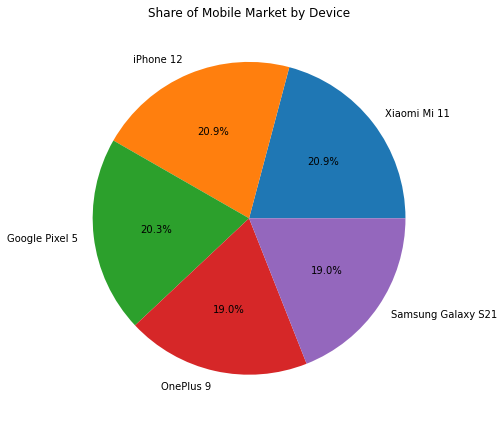

In [63]:
viz.plot_phone_market_share(mobile_user)

In [64]:
# operating_system as variable
operating_system_counts = mobile_user['operating_system'].value_counts().to_frame()
operating_system_counts.rename(columns={'operating_system': 'value_counts'}, inplace=True)
operating_system_counts.index.name = 'operating_system'
operating_system_counts.head().round(2)

,value_counts
operating_system,
Android,554
iOS,146


In [65]:
# gender as variable
gender_counts = mobile_user['gender'].value_counts().to_frame()
gender_counts.rename(columns={'gender': 'value_counts'}, inplace=True)
gender_counts.index.name = 'gender'
gender_counts.head()

,value_counts
gender,
Male,364
Female,336


In [66]:
# user_behavior_class as variable
mobile_user['user_behavior_class'].value_counts()

2    146
3    143
4    139
5    136
1    136
Name: user_behavior_class, dtype: int64

In [67]:
avg_B_drain = round(mobile_user.groupby(['device_model'])[['battery_drain_mah_per_day']].mean(),3)
avg_B_drain.head()           

,battery_drain_mah_per_day
device_model,
Google Pixel 5,1475.676
OnePlus 9,1523.850
Samsung Galaxy S21,1504.571
Xiaomi Mi 11,1528.877
iPhone 12,1589.514


In [68]:
avg_osb_drain = round(mobile_user.groupby(['operating_system'])[['battery_drain_mah_per_day']].mean(),3)
avg_osb_drain

,battery_drain_mah_per_day
operating_system,
Android,1508.199
iOS,1589.514


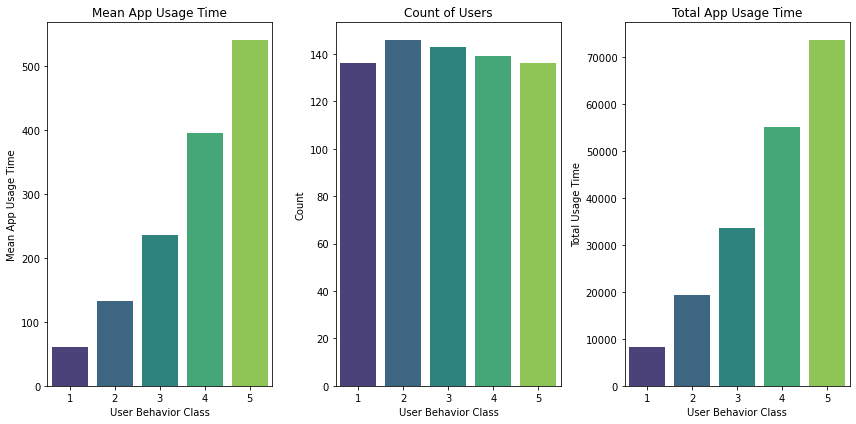

In [69]:
viz.plot_user_behavior_class(mobile_user)

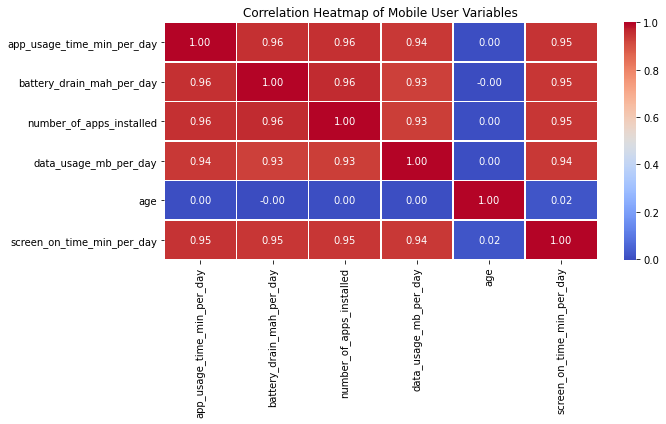

In [70]:
viz.plot_correlation_heatmap(mobile_user)

In [71]:
corr_data = mobile_user.drop(
    columns=['user_id', 'user_behavior_class']
)


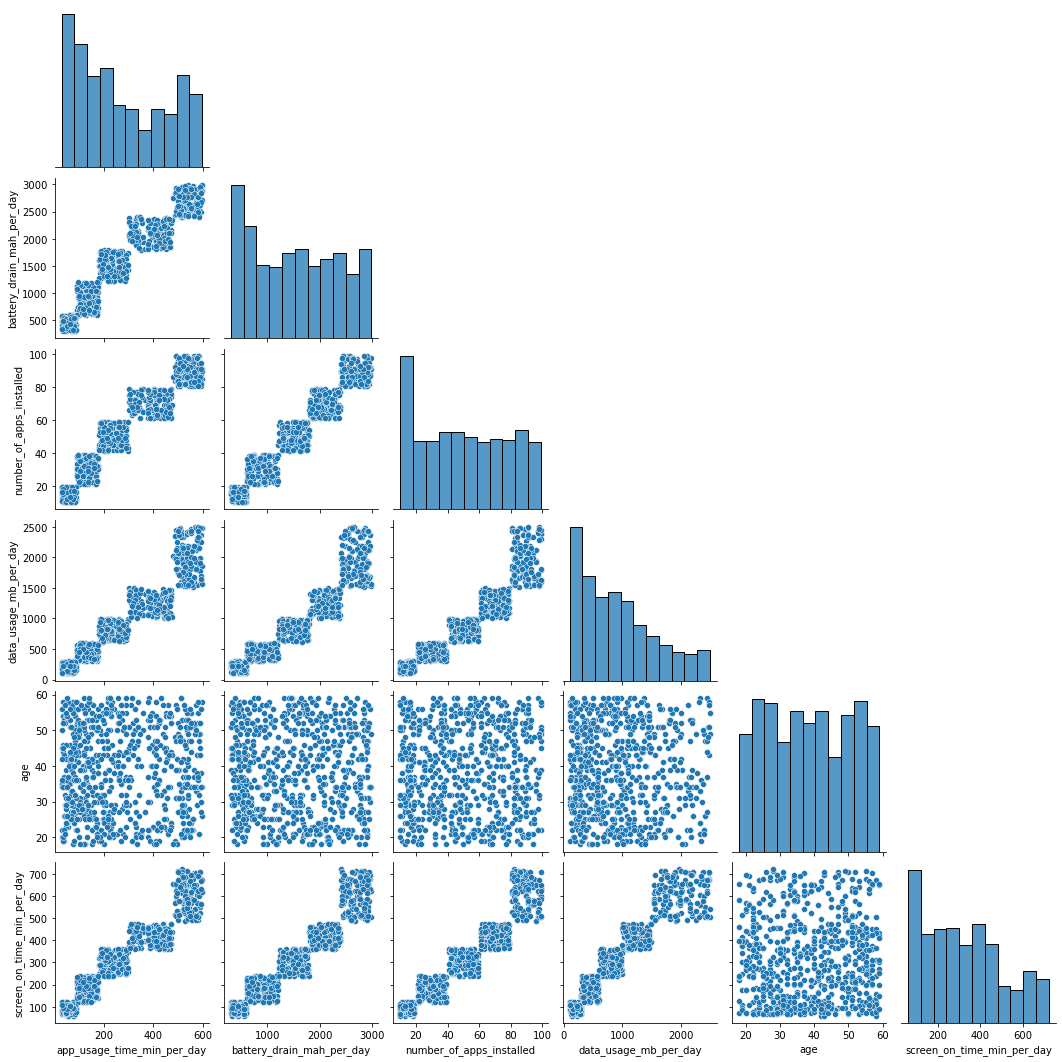

In [72]:
sns.pairplot(
    corr_data,
    corner=True
)

**1. OPERATING SYSTEM  vs BATTERY DRAIN PER DAY.**

Null Hypothesis (Ho):

    There is no difference in average battery drain between the operating systems.

        
Alternative Hypothesis (H1):


    There is a difference in average battery drain between the operating systems.


       

Standard choice:

alpha = 0.05

This means accepting 5% risk of committing a type I error, that is rejecting the Null Hypothesis when it is actually true. 

We are comparing the sample means between two independent operating systems; Android and iOS. Therefore, I will use a two-sample t-test.

In [73]:
st.operating_system_battery_ttest(mobile_user)

T-statistic:  -1.06718724967966
P-value:  0.28625625395745274


(-1.06718724967966, 0.28625625395745274)

**2. DATA USAGE vs MOBILE DEVICES**

I want to determine whether the means of 5 device models are significantly different from each other.  I will therefore utilize the Analysis of Variance (ANOVA). To that end, I will do the pre activities that follows: 
* Define the observations for each class
* Check the ANOVA assumptions for: 
    * Independent observations
    * Approximately normal distributions
    * Homogeneity of variance
* Before proceeding to the ANOVA test.

**APPROXIMATE NORMALITY**

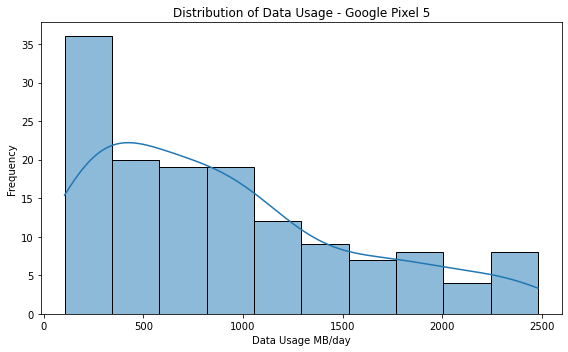

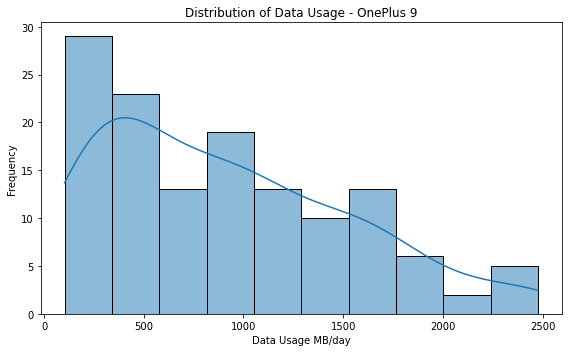

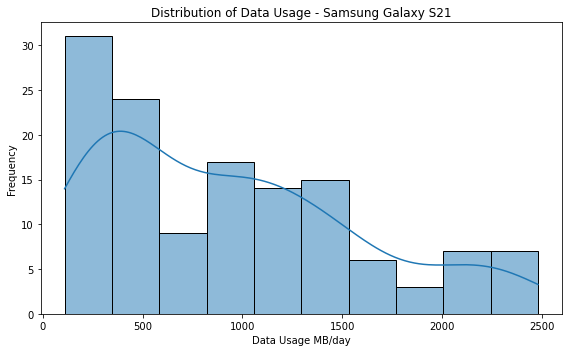

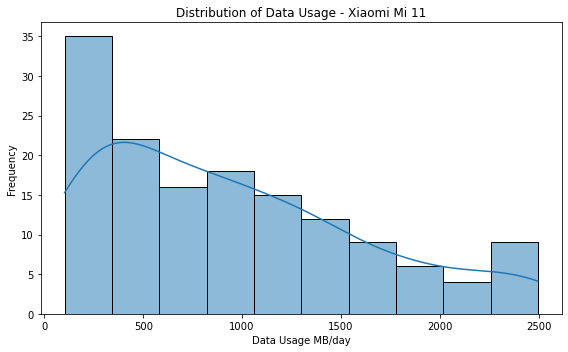

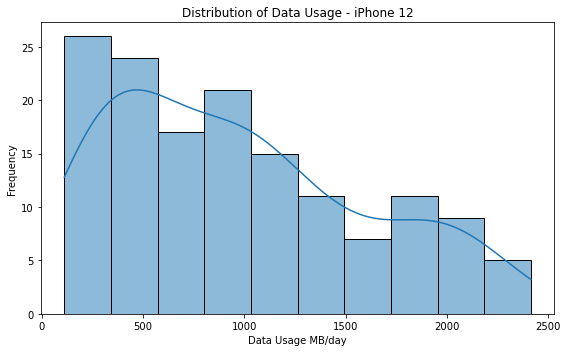

In [74]:
st.check_normality_histograms(mobile_user)

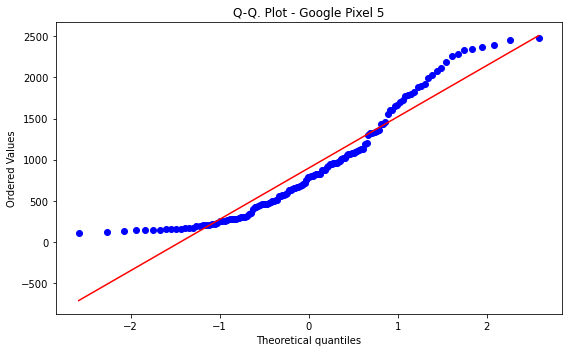

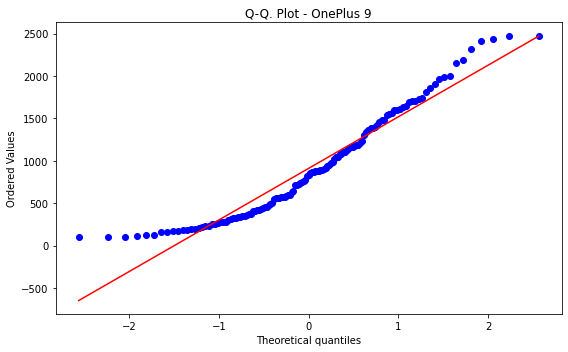

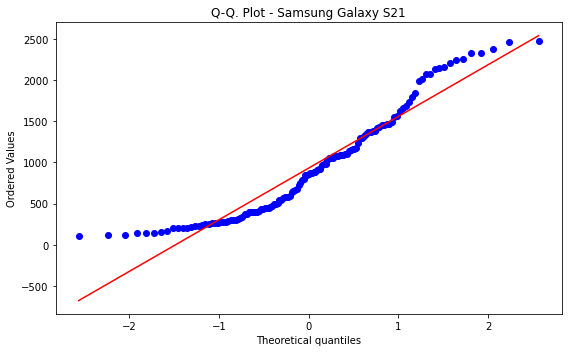

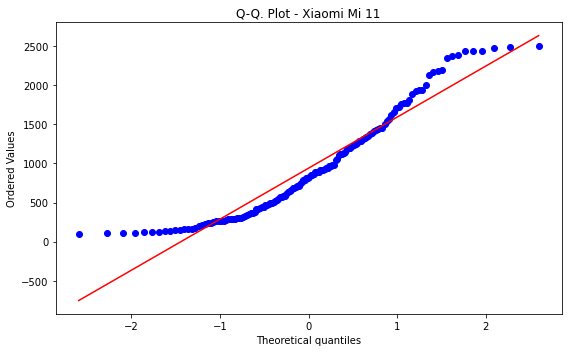

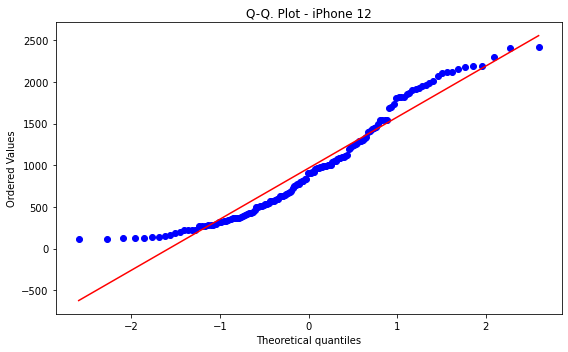

In [75]:
st.check_normality_qqplots(mobile_user)

**Shapiro-Wilk Test**

In [76]:
st.check_shapiro_wilk_test(mobile_user)

Google Pixel 5
Statistic:  0.9099442362785339
P-value: 9.713293280810831e-08
OnePlus 9
Statistic:  0.9311231374740601
P-value: 4.154976977588376e-06
Samsung Galaxy S21
Statistic:  0.9186419248580933
P-value: 6.751332080057182e-07
Xiaomi Mi 11
Statistic:  0.9187466502189636
P-value: 2.4110616436701093e-07
iPhone 12
Statistic:  0.9347851276397705
P-value: 2.8737217689922545e-06


**HOMOGENEITY OF VARIANCE**

In [77]:
st.check_homogeneity(mobile_user)

Levine Statistic: 0.20923388682525962
P-value: 0.9333326035414634


(0.20923388682525962, 0.9333326035414634)

In [78]:
st.device_model_data_usage_anova(mobile_user)

F-statistic: 0.23975412553050754
P-value: 0.9158390350829677


(0.23975412553050754, 0.9158390350829677)